# Single Session Prediction

Only consider a single session in isolation. Use zero-shot inductive biases that Chronos 2 has, but probably not that good for our challenge.

### Read a session data

In [23]:
import pandas as pd

# Read the seen and unseen data
train_seen = pd.read_parquet("../data/bars_seen_train.parquet")
train_unseen = pd.read_parquet("../data/bars_unseen_train.parquet")

# Bring in sentiment data
# sentiment_df = pd.read_csv("../sentiment_overview.csv")

# train_seen = train_seen.merge(sentiment_df, on=['session', 'bar_ix'], how='left')
# train_unseen = train_unseen.merge(sentiment_df, on=['session', 'bar_ix'], how='left')

# # Drop some sentiment columns (might re-add later)
# train_seen = train_seen.drop(columns=["headline"])
# train_unseen = train_unseen.drop(columns=["headline"])

# train_seen = train_seen.groupby(['session', 'bar_ix']).sample(n=1, random_state=42).reset_index(drop=True)
# train_unseen = train_unseen.groupby(['session', 'bar_ix']).sample(n=1, random_state=42).reset_index(drop=True)

# Already set the timestamps
start_date = pd.to_datetime('2000-01-01')

train_seen['timestamp'] = start_date + pd.to_timedelta(train_seen['bar_ix'], unit='D')
train_unseen['timestamp'] = start_date + pd.to_timedelta(train_unseen['bar_ix'], unit='D')


display(train_seen)
display(train_unseen)



,bar_ix,session,open,high,low,close,timestamp
0,0,0,1.0000,1.0029,0.9986,0.9999,2000-01-01
1,0,1,1.0000,1.0024,0.9980,1.0011,2000-01-01
2,0,2,1.0000,1.0005,0.9952,0.9957,2000-01-01
3,0,3,1.0000,1.0008,0.9986,1.0008,2000-01-01
4,0,4,1.0000,1.0031,0.9996,1.0009,2000-01-01
...,...,...,...,...,...,...,...
1029995,49,995,0.9886,0.9913,0.9876,0.9913,2000-02-19
1029996,49,996,0.9916,0.9941,0.9899,0.9915,2000-02-19
1029997,49,997,0.9796,0.9801,0.9779,0.9796,2000-02-19
1029998,49,998,1.0123,1.0168,1.0123,1.0142,2000-02-19


,bar_ix,session,open,high,low,close,timestamp
1050000,50,0,1.0318,1.0375,1.0318,1.0367,2000-02-20
1050001,50,1,1.0283,1.0297,1.0261,1.0282,2000-02-20
1050002,50,2,1.0204,1.0217,1.0179,1.0202,2000-02-20
1050003,50,3,1.0117,1.0129,1.0112,1.0126,2000-02-20
1050004,50,4,1.0281,1.0296,1.0263,1.0274,2000-02-20
...,...,...,...,...,...,...,...
2079995,99,995,0.9833,0.9837,0.9811,0.9812,2000-04-09
2079996,99,996,1.0684,1.0685,1.0638,1.0661,2000-04-09
2079997,99,997,1.0058,1.0060,1.0019,1.0028,2000-04-09
2079998,99,998,1.0014,1.0033,1.0001,1.0028,2000-04-09


### Predict with Chronos 2

In [24]:
import pandas as pd  # requires: pip install 'pandas[pyarrow]'
from chronos import Chronos2Pipeline

def predict_session(SESSION_ID: int, seen=train_seen, unseen=train_unseen):
    # Prepare the session
    seen = seen[seen["session"] == SESSION_ID]
    unseen = unseen[unseen["session"] == SESSION_ID]

    pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="mps")

    pred_df = pipeline.predict_df(
        seen,
        future_df=None,
        prediction_length=50,  # Number of steps to forecast
        quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
        id_column="session",  # Column identifying different time series
        timestamp_column="timestamp",  # Column with datetime information
        target="close",  # Column(s) with time series values to predict
        cross_learning=True
    )

    import matplotlib.pyplot as plt  # requires: pip install matplotlib

    ts_context = seen.set_index("timestamp")["close"]
    ts_pred = pred_df.set_index("timestamp")
    ts_ground_truth = unseen.set_index("timestamp")["close"]

    ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
    ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
    ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
    plt.fill_between(
        ts_pred.index,
        ts_pred["0.1"],
        ts_pred["0.9"],
        alpha=0.7,
        label="prediction interval",
        color="xkcd:light lavender",
    )
    plt.legend()
    plt.show()

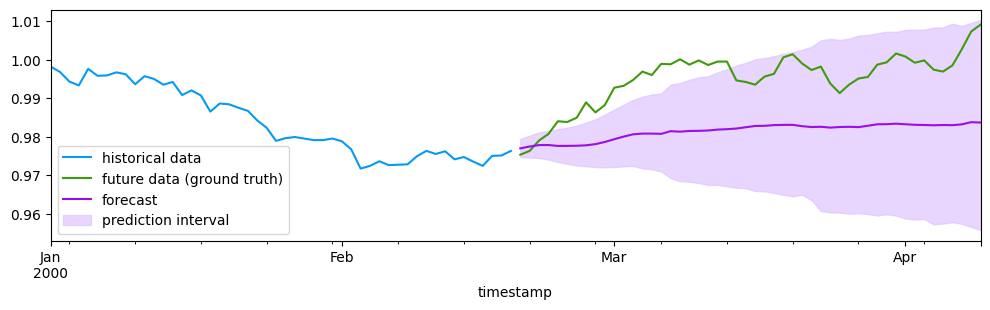

In [30]:
predict_session(SESSION_ID=789)

# Predict entire sequence

Take the entire group of time-series in context when predicting.

In [31]:

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="mps")

SLIDING_WINDOW_SIZE = 5 
TOTAL_FORECAST_STEPS = 50
all_pred_df = pd.DataFrame()

all_pred_df = pipeline.predict_df(
    train_seen,
    prediction_length=50,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="session",
    timestamp_column="timestamp",
    target="close",
)

# Create a copy so we don't mutate the original training data
# current_history = train_seen.copy()

# for _ in range(TOTAL_FORECAST_STEPS // SLIDING_WINDOW_SIZE):
#     # 1. Generate predictions for the next window
#     batch_preds_df = pipeline.predict_df(
#         current_history,
#         prediction_length=SLIDING_WINDOW_SIZE,
#         quantile_levels=[0.1, 0.5, 0.9],
#         id_column="session",
#         timestamp_column="timestamp",
#         target="close",
#     )
    
#     # 2. Store the predictions (Fixing the .concat syntax)
#     all_pred_df = pd.concat([all_pred_df, batch_preds_df])
    
#     # 3. "Slide" the window: Prepare predictions to be used as future input
#     # We use the median (0.5) forecast as the "actual" value for the next iteration
#     new_observations = batch_preds_df.reset_index()
#     new_observations['close'] = new_observations['0.5'] # Use the 50th percentile
    
#     # Keep only the columns needed for the training data format
#     new_observations = new_observations[["session", "timestamp", "close"]]
    
#     # Update the history with the values we just "invented"
#     current_history = pd.concat([current_history, new_observations], ignore_index=True)



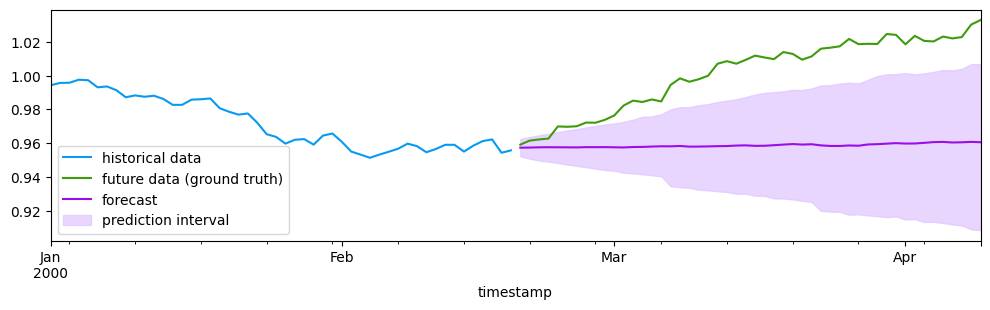

In [32]:
import matplotlib.pyplot as plt

DISPLAY_SESSION_ID = 129

display_seen = train_seen[train_seen["session"] == DISPLAY_SESSION_ID]
display_unseen = train_unseen[train_unseen["session"] == DISPLAY_SESSION_ID]
display_all_pred_df = all_pred_df[all_pred_df["session"] == DISPLAY_SESSION_ID]

ts_context = display_seen.set_index("timestamp")["close"]
ts_pred = display_all_pred_df.set_index("timestamp")
ts_ground_truth = display_unseen.set_index("timestamp")["close"]

ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.7,
    label="prediction interval",
    color="xkcd:light lavender",
)
plt.legend()
plt.show()

## Convert to a submission

In [33]:
import numpy as np

# Close at bar 49 (halfway) for each session
close_halfway = train_seen.groupby('session')['close'].last().rename('close_halfway')

# At bar 99: median prediction and CI bounds (q10, q90) for each session
pred_last = all_pred_df.groupby('session').last()[['predictions', '0.1', '0.9']]
pred_last.columns = ['pred_close_end', 'q10_end', 'q90_end']

# At bar 49 + SLIDING_WINDOW = most accurate estimate of uncertainty, since the rest are biased by passed predictions of the model
# first_pred_mid = all_pred_df.groupby('session').nth(SLIDING_WINDOW_SIZE-1)[['predictions', '0.1', '0.9']]
# display(first_pred_mid)
# first_pred_mid.columns = ['pred_close_first_pred', 'q10_first_pred', 'q90_first_pred']

submission_df = close_halfway.to_frame().join(pred_last)#.join(first_pred_mid)

EPSILON = 0.002  # minimum predicted return to trade (0.2%)
EPSILON_LONG = EPSILON
EPSILON_SHORT =  EPSILON  # Maintaining your asymmetric threshold
MAX_POSITION = 1.0           # Cap to prevent extreme leverage
CI_FLOOR = 1e-4              # Prevents division by zero or extreme signals

# 1. Calculate returns and uncertainty
# print(submission_df['q90_first_pred'])
# print(submission_df['q10_first_pred'])
submission_df['predicted_return'] = (submission_df['pred_close_end'] / submission_df['close_halfway']) - 1
submission_df['ci_width'] = (submission_df['q90_end'] - submission_df['q10_end']) / submission_df['close_halfway']

# 2. Calculate the raw signal 
# We use np.maximum to ensure we never divide by zero or a sub-atomic CI width
submission_df['signal'] = submission_df['predicted_return'] / submission_df['ci_width'].clip(lower=CI_FLOOR)

# 3. Define Entry Conditions
# Long if return > EPSILON; Short if return < -5 * EPSILON
long_condition = submission_df['predicted_return'] > EPSILON_LONG
short_condition = submission_df['predicted_return'] < -EPSILON_SHORT

# 4. Generate Target Position and Clip
# Apply signal where conditions are met, otherwise 0.0
submission_df['target_position'] = np.where(
    long_condition, #| short_condition,
    submission_df['signal'],
    0.0
)

# 5. Final Risk Overlay
# Ensure positions don't exceed your maximum allowed leverage/allocation
submission_df['target_position'] = submission_df['target_position'].clip(-MAX_POSITION, MAX_POSITION)


submission = submission_df[['target_position']].reset_index()[['session', 'target_position']].sort_values('session')
n_trading = (submission['target_position'] != 0).sum()
display(submission.head(10))
print(f"Trading {n_trading}/{len(submission)} sessions (epsilon={EPSILON})")

submission.describe()


,session,target_position
0,0,0.000000
1,1,0.000000
2,2,0.000000
3,3,0.000000
4,4,0.134003
5,5,0.000000
6,6,0.000000
7,7,0.000000
8,8,0.450506
9,9,0.035696


Trading 306/1000 sessions (epsilon=0.002)


,session,target_position
count,1000.000000,1000.000000
mean,499.500000,0.048154
std,288.819436,0.103975
min,0.000000,0.000000
25%,249.750000,0.000000
50%,499.500000,0.000000
75%,749.250000,0.058811
max,999.000000,1.000000


## Compute Sharpe

Sharpe ratio on train (Chronos-2 median forecast): 1.0106
Mean PnL: 0.000108
Std  PnL: 0.001714
Win rate: 16.20%


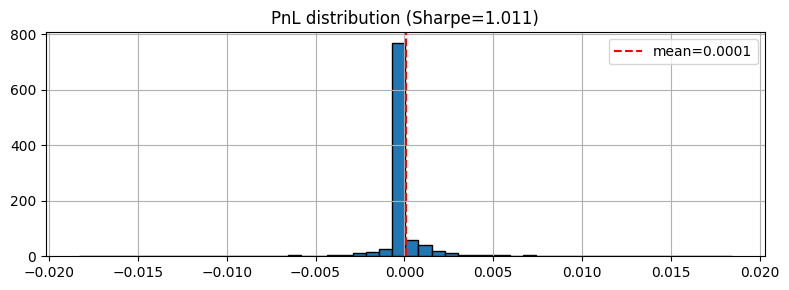

In [12]:
import numpy as np

# Actual close at bar 99 (end of session)
close_end = train_unseen.groupby('session')['close'].last().rename('close_end')

eval_df = submission.set_index('session').join(close_halfway).join(close_end)

# pnl_i = target_position_i * (close_end_i / close_halfway_i - 1)
eval_df['pnl'] = eval_df['target_position'] * (eval_df['close_end'] / eval_df['close_halfway'] - 1)

sharpe = np.mean(eval_df['pnl']) / np.std(eval_df['pnl']) * 16

print(f"Sharpe ratio on train (Chronos-2 median forecast): {sharpe:.4f}")
print(f"Mean PnL: {eval_df['pnl'].mean():.6f}")
print(f"Std  PnL: {eval_df['pnl'].std():.6f}")
print(f"Win rate: {(eval_df['pnl'] > 0).mean():.2%}")

import matplotlib.pyplot as plt
eval_df['pnl'].hist(bins=50, figsize=(8, 3), edgecolor='k')
plt.axvline(eval_df['pnl'].mean(), color='red', linestyle='--', label=f'mean={eval_df["pnl"].mean():.4f}')
plt.title(f'PnL distribution (Sharpe={sharpe:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# Submit submission on public and private data

In [13]:
import pandas as pd

public_seen = pd.read_parquet("../data/bars_seen_public_test.parquet")
private_seen = pd.read_parquet("../data/bars_seen_private_test.parquet")

In [34]:
import pandas as pd
import numpy as np
from chronos import Chronos2Pipeline

# PUBLIC DATASET
sentiment_df_pub = pd.read_csv("../anna/headline_stats_seen_pubtest.csv")
public_seen = public_seen.merge(sentiment_df_pub, on=['session', 'bar_ix'], how='left')
public_seen = public_seen.drop(columns=["headline"])
public_seen = public_seen.groupby(['session', 'bar_ix']).sample(n=1, random_state=42).reset_index(drop=True)

# PRIVATE DATASET
sentiment_df_priv = pd.read_csv("../anna/headline_stats_seen_privtest.csv")
private_seen = private_seen.merge(sentiment_df_priv, on=['session', 'bar_ix'], how='left')
private_seen = private_seen.drop(columns=["headline"])
private_seen = private_seen.groupby(['session', 'bar_ix']).sample(n=1, random_state=42).reset_index(drop=True)

start_date = pd.to_datetime('2000-01-01')
public_seen['timestamp'] = start_date + pd.to_timedelta(public_seen['bar_ix'], unit='D')
private_seen['timestamp'] = start_date + pd.to_timedelta(private_seen['bar_ix'], unit='D')

def make_submission(seen_df):
    pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="mps")
    
    EPSILON = 0

    pred_df = pipeline.predict_df(
        seen_df,
        future_df=None,
        prediction_length=50,
        quantile_levels=[0.1, 0.5, 0.9],
        id_column='session',
        timestamp_column='timestamp',
        target='close',
    )

    close_halfway = seen_df.groupby('session')['close'].last().rename('close_halfway')

    pred_last = pred_df.groupby('session').last()[['predictions', '0.1', '0.9']]
    pred_last.columns = ['pred_close_end', 'q10_end', 'q90_end']

    df = close_halfway.to_frame().join(pred_last)

    predicted_return = df['pred_close_end'] / df['close_halfway'] - 1
    ci_width = (df['q90_end'] - df['q10_end']) / df['close_halfway']
    signal = predicted_return / ci_width

    df['target_position'] = np.where(
        predicted_return > EPSILON,
        signal,
        0.0,
    )

    return df[['target_position']].reset_index()[['session', 'target_position']].sort_values('session')

print("Predicting public test sessions...")
public_submission = make_submission(public_seen)
print(f"  {len(public_submission)} sessions, IDs {public_submission['session'].min()}–{public_submission['session'].max()}")

print("Predicting private test sessions...")
private_submission = make_submission(private_seen)
print(f"  {len(private_submission)} sessions, IDs {private_submission['session'].min()}–{private_submission['session'].max()}")

final_submission = pd.concat([public_submission, private_submission], ignore_index=True)
final_submission.to_csv('submission_final.csv', index=False)
print(f"\nSaved submission_final.csv ({len(final_submission)} total rows)")
display(final_submission.head())
display(final_submission.tail())

Predicting public test sessions...
  10000 sessions, IDs 1000–10999
Predicting private test sessions...
  10000 sessions, IDs 11000–20999

Saved submission_final.csv (20000 total rows)


,session,target_position
0,1000,0.0
1,1001,0.0
2,1002,0.0
3,1003,0.0
4,1004,0.0


,session,target_position
19995,20995,0.255432
19996,20996,0.011845
19997,20997,0.172903
19998,20998,0.020472
19999,20999,0.078230
